# Damages by country - LitPop data

This notebook computes damages, by merging LitPop data and cyclone tracks and using the damage function emanuel_2011. The cyclone tracks must have the variable country (it can be added to the code output by running Add_country_to_tracks.ipynb).

The results are however not satisfying.

## Imports

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import pyarrow.compute as pc
import pyarrow.csv as pv
import numpy as np
import polars as pl
import geopandas as gpd
from src.damages.damage_functions import emanuel_2011
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import tarfile
import io
import os
import gc

from scipy.spatial import cKDTree
from pyproj import Transformer
import psutil

pd.set_option('display.max_columns', 500)

## Configuration

In [5]:
# Configuration du modèle et expérience
model = "ACCESS-CM2"
experiment = "ssp245"

# Chemins des données
tracks_dir = Path(f"../data/output/catherina/intensified_tracks_with_country/{model}/{experiment}")
litpop_tar_path = Path("../data/input/wealth_densities/litpop/litpop_full/LitPop_v1_2.tar")
output_dir = Path(f"../data/output/damages/by_country/{model}/{experiment}")

# Créer le répertoire de sortie
output_dir.mkdir(parents=True, exist_ok=True)

print(f"✓ Modèle: {model}")
print(f"✓ Expérience: {experiment}")
print(f"✓ Répertoire tracks: {tracks_dir}")
print(f"✓ Archive LitPop: {litpop_tar_path}")
print(f"✓ Répertoire sortie: {output_dir}")

✓ Modèle: ACCESS-CM2
✓ Expérience: ssp245
✓ Répertoire tracks: ../data/output/catherina/intensified_tracks_with_country/ACCESS-CM2/ssp245
✓ Archive LitPop: ../data/input/wealth_densities/litpop/litpop_full/LitPop_v1_2.tar
✓ Répertoire sortie: ../data/output/damages/by_country/ACCESS-CM2/ssp245


## Charger le dataset des tracks

In [6]:
# Charger le dataset partitionné des tracks
tracks_ds = ds.dataset(tracks_dir, partitioning="hive")

# Récupérer un sample pour explorer
sample = tracks_ds.head(1000).to_pandas()
print(f"Colonnes disponibles ({len(sample.columns)}):")
print(list(sample.columns))
print(f"\nFormes des données: {sample.shape}")
print(f"\nPremières lignes:")
print(sample.head())

Colonnes disponibles (57):
['SID', 'step', 'index', 'lat_left', 'lon_left', 'datetime', 'time', 'y', 'x', 'nshr', 'mslp_hpa', 'T_strat', 'SST', 'height', 'lat_right', 'lon_right', 'distance_track_env', 'thermo_eff', 'basin', 'A', 'B', 'C', 'a', 'b', 'c_0', 'c_1', 'c_2', 'c_3', 'sigma_pc', 'q_env', 'wind_speed', 'delta_pc_hpa', 'pc_hpa', 'eps_pc', 'is_on_land', 'dist2coast_meters', 'V_0', 't_L_steps', 'final_wind_speed', 'delta_pc_hpa_1', 'pc_hpa_1', 'final_wind_1', 'final_wind_2', 'V_0_1', 't_L_steps_1', 'pc_hpa_1_eff', 'qc', 'delta_Sm', 'X', 'MPI_hpa', 'mpd_hpa', 'mslp_mpd_diff_hpa', 'month', 'country', 'country_iso2', 'seed', 'year']

Formes des données: (1000, 57)

Premières lignes:
          SID  step  index   lat_left    lon_left            datetime  \
0  1009568400     0      0  12.500484 -106.500000 2025-10-01 00:00:00   
1  1009568400     1      1  12.461908 -106.572353 2025-10-01 03:00:00   
2  1009568400     2      2  12.434372 -106.662559 2025-10-01 06:00:00   
3  1009568400

## Obtenir la liste des pays disponibles

In [7]:
# Obtenir la liste unique des pays dans les données de tracks
countries_in_tracks = pc.unique(tracks_ds.to_table(["country_iso2"]).column("country_iso2")).to_pylist()
countries_in_tracks = [c for c in countries_in_tracks if c is not None]
countries_in_tracks = sorted(countries_in_tracks)

print(f"Nombre de pays: {len(countries_in_tracks)}")
print(f"Pays: {countries_in_tracks}")

Nombre de pays: 74
Pays: ['-99', 'AE', 'AF', 'AU', 'BD', 'BF', 'BS', 'BT', 'BZ', 'CA', 'CN', 'CN-TW', 'CO', 'CR', 'CU', 'DJ', 'DO', 'DZ', 'EG', 'ES', 'ET', 'FJ', 'GB', 'GM', 'GT', 'GW', 'HN', 'HT', 'ID', 'IE', 'IN', 'IR', 'IT', 'JM', 'JP', 'KH', 'KR', 'KZ', 'LA', 'LK', 'MG', 'MK', 'MM', 'MX', 'MY', 'MZ', 'NC', 'NG', 'NI', 'NP', 'NZ', 'OM', 'PA', 'PG', 'PH', 'PK', 'PR', 'PT', 'RU', 'SA', 'SB', 'SD', 'SO', 'SV', 'TD', 'TH', 'TM', 'US', 'UZ', 'VE', 'VN', 'VU', 'YE', 'ZA']


## Explorer l'archive LitPop

In [8]:
# Lister les fichiers dans l'archive LitPop
litpop_files = {}

with tarfile.open(litpop_tar_path, "r") as tar:
    for member in tar:
        if member.isfile():
            filename = member.name
            # Extraire le code pays ISO3 du nom du fichier
            if "LitPop_pc_30arcsec_" in filename:
                iso3 = filename.split("_")[-1].split(".")[0]
                litpop_files[iso3] = filename

print(f"Nombre de pays dans LitPop: {len(litpop_files)}")
print(f"Exemples: {list(litpop_files.items())[:5]}")

Nombre de pays dans LitPop: 224
Exemples: [('LTU', 'LitPop_v1_2/LitPop_pc_30arcsec_LTU.csv'), ('BWA', 'LitPop_v1_2/LitPop_pc_30arcsec_BWA.csv'), ('IRQ', 'LitPop_v1_2/LitPop_pc_30arcsec_IRQ.csv'), ('MHL', 'LitPop_v1_2/LitPop_pc_30arcsec_MHL.csv'), ('SVN', 'LitPop_v1_2/LitPop_pc_30arcsec_SVN.csv')]


## Mapping ISO3 <-> ISO2

In [9]:
# Créer un mapping entre ISO3 et ISO2
# En utilisant geopandas qui a les données des pays
countries_geodf = gpd.read_file(
    "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
)

# Créer le dictionnaire ISO3 -> ISO2
iso3_to_iso2 = dict(zip(
    countries_geodf["ADM0_A3"],
    countries_geodf["ISO_A2"]
))

print(f"Exemple de mapping: USA -> {iso3_to_iso2.get('USA')}")
print(f"Exemple de mapping: GBR -> {iso3_to_iso2.get('GBR')}")

ERROR 1: PROJ: proj_create_from_database: Open of /home/tiphanie/projets_python/catherina/.pixi/envs/default/share/proj failed


Exemple de mapping: USA -> US
Exemple de mapping: GBR -> GB


## Fonction pour charger LitPop par pays

In [10]:
def load_litpop_country(iso3_code, litpop_tar_path):
    """
    Charge les données LitPop pour un pays donné depuis le fichier tar.
    
    Parameters:
    -----------
    iso3_code : str
        Code ISO3 du pays (ex: "USA", "GBR")
    litpop_tar_path : Path
        Chemin vers l'archive LitPop
    
    Returns:
    --------
    pd.DataFrame
        DataFrame avec colonnes: lon, lat, value
    """
    file_path = f"LitPop_v1_2/LitPop_pc_30arcsec_{iso3_code}.csv"
    
    with tarfile.open(litpop_tar_path, "r:") as tar:
        try:
            member = tar.getmember(file_path)
            f = tar.extractfile(member)
            
            # Lire le CSV avec pyarrow en streaming pour limiter la mémoire
            csv_reader = pv.open_csv(
                f,
                read_options=pv.ReadOptions(block_size=1 << 20),
            )
            table = csv_reader.read_all()
            df = table.to_pandas()
            
            # Renommer les colonnes pour la cohérence
            if len(df.columns) >= 4:
                df.columns = ["value", "lat", "lon", "region_id"] + list(df.columns[4:])
            else:
                df.columns = ["value", "lat", "lon", "region_id"]
            
            return df
        except KeyError:
            print(f"Avertissement: {iso3_code} non trouvé dans l'archive")
            return None


# Test
# Ce test permet de vérifier que la fonction peut ouvrir l'archive et lire un pays.
test_df = load_litpop_country("USA", litpop_tar_path)
if test_df is not None:
    print(f"Test USA: {test_df.shape}")
    print(test_df.head())
    print(f"Valeur totale: {test_df['value'].sum():,.0f}")

Test USA: (16075317, 4)
   value        lat         lon  region_id
0    0.0  51.279167 -179.137500        840
1    0.0  51.270833 -179.137500        840
2    0.0  51.262500 -179.137500        840
3    0.0  51.279167 -179.129167        840
4    0.0  51.270833 -179.129167        840
Valeur totale: 55,599,336,231,102


## Fonction pour calculer les dommages par pays

In [11]:
def process_country_damages(
    iso2_code,
    iso3_code,
    tracks_ds,
    litpop_tar_path,
    output_dir,
):
    """
    Calcule les dommages pour un pays donné et les sauvegarde.
    
    Parameters:
    -----------
    iso2_code : str
        Code ISO2 du pays
    iso3_code : str
        Code ISO3 du pays (pour chercher dans LitPop)
    tracks_ds : pyarrow.dataset
        Dataset des tracks
    litpop_tar_path : Path
        Chemin vers l'archive LitPop
    output_dir : Path
        Répertoire de sortie
    """
    
    def mem():
        return psutil.Process(os.getpid()).memory_info().rss / 1e9
    
    print(f"\n{'='*60}")
    print(f"Pays: {iso2_code} ({iso3_code})")
    print(f"{'='*60}")
    print(f"[START RAM] {mem():.2f} GB")
    
    output_file = output_dir / f"{iso2_code}.parquet"
    temp_output_file = output_dir / f"{iso2_code}.parquet.tmp"
    if output_file.exists() and output_file.stat().st_size > 0:
        print(f"  ➜ Fichier déjà existant, pays ignoré : {output_file}")
        return True
    
    # Charger les données LitPop
    print(f"Chargement LitPop...")
    litpop_df = load_litpop_country(iso3_code, litpop_tar_path)
    
    if litpop_df is None or len(litpop_df) == 0:
        print(f"  ✗ Aucune donnée LitPop pour {iso2_code}")
        return False
    
    print(f"  ✓ LitPop chargé: {litpop_df.shape}")
    
    # Transformer les coordonnées en Mercator
    print(f"Projection spatiale...")
    transformer = Transformer.from_crs(
        "EPSG:4326",
        "EPSG:3857",
        always_xy=True,
    )
    
    lit_x, lit_y = transformer.transform(
        litpop_df["lon"].values,
        litpop_df["lat"].values,
    )
    lit_coords = np.column_stack((lit_x, lit_y)).astype(np.float32)
    tree = cKDTree(lit_coords)
    
    lit_val = litpop_df["value"].to_numpy(dtype=np.float32)
    lit_lon = litpop_df["lon"].to_numpy(dtype=np.float32)
    lit_lat = litpop_df["lat"].to_numpy(dtype=np.float32)
    
    print(f"  ✓ Arbre spatial créé")
    
    # Writer incrémental pour limiter la mémoire
    print(f"Fusion des données et écriture incrémentale...")
    writer = None
    n_written = 0
    batch_size = 50_000
    success = True
    
    try:
        for batch in tracks_ds.to_batches(
            filter=(ds.field("country_iso2") == iso2_code),
            batch_size=batch_size,
            columns=[
                "seed",
                "year",
                "month",
                "lat_left",
                "lon_left",
                "final_wind_speed",
            ],
        ):
            batch_df = batch.to_pandas()
            if len(batch_df) == 0:
                continue
            
            x, y = transformer.transform(
                batch_df["lon_left"].values,
                batch_df["lat_left"].values,
            )
            coords = np.column_stack((x, y)).astype(np.float32, copy=False)
            
            _, idx = tree.query(coords, k=1, workers=1)
            
            litpop_values = lit_val[idx]
            litpop_lon = lit_lon[idx]
            litpop_lat = lit_lat[idx]
            
            relative_losses = emanuel_2011(batch_df["final_wind_speed"].values)
            absolute_losses = relative_losses * litpop_values
            
            output_table = pa.table(
                {
                    "country_iso2": np.full(len(batch_df), iso2_code, dtype=object),
                    "seed": batch_df["seed"].values,
                    "year": batch_df["year"].values,
                    "month": batch_df["month"].values,
                    "track_lat": batch_df["lat_left"].values,
                    "track_lon": batch_df["lon_left"].values,
                    "litpop_lat": litpop_lat,
                    "litpop_lon": litpop_lon,
                    "final_wind_speed": batch_df["final_wind_speed"].values,
                    "litpop_value": litpop_values,
                    "relative_losses": relative_losses,
                    "absolute_losses": absolute_losses,
                }
            )
            
            if writer is None:
                writer = pq.ParquetWriter(
                    temp_output_file,
                    output_table.schema,
                    compression="zstd",
                )
            writer.write_table(output_table)
            n_written += len(batch_df)
            del batch_df, output_table, coords, idx, litpop_values, litpop_lon, litpop_lat, relative_losses, absolute_losses
            gc.collect()
    except Exception as e:
        print(f"  ✗ Erreur pendant le traitement de {iso2_code} : {e}")
        success = False
    finally:
        if writer is not None:
            writer.close()
    
    if not success or n_written == 0:
        if temp_output_file.exists():
            temp_output_file.unlink()
        if not success:
            print(f"  ✗ Échec du calcul pour {iso2_code}")
        else:
            print(f"  ✗ Aucun enregistrement écrit pour {iso2_code}")
        return False
    
    if temp_output_file.exists():
        temp_output_file.replace(output_file)
    
    print(f"  ✓ Sauvegardé: {output_file} ({n_written:,} lignes)")
    print(f"[END RAM] {mem():.2f} GB")
    
    del (
        litpop_df,
        lit_x,
        lit_y,
        lit_coords,
        tree,
        lit_val,
        lit_lon,
        lit_lat,
    )
    gc.collect()
    return True

## Traiter tous les pays

In [18]:
# Identifier les pays déjà traités et ceux qui ont échoué
import os

completed_files = [f.stem for f in output_dir.glob("*.parquet")]
failed_file_path = output_dir / "failed_countries.txt"

# Lire les pays échoués s'il existe
failed_from_previous = []
if failed_file_path.exists():
    failed_from_previous = failed_file_path.read_text().strip().split("\n")
    failed_from_previous = [c.strip() for c in failed_from_previous if c.strip()]

# Identifier les pays à traiter
already_done = set(completed_files)
still_to_do = [c for c in countries_in_tracks if c not in already_done]
needs_retry = [c for c in countries_in_tracks if c in failed_from_previous and c not in already_done]

print(f"╔{'='*60}╗")
print(f"║ DIAGNOSTIC DE PROGRESSION                              ║")
print(f"╚{'='*60}╝")
print(f"\n✓ Pays traités avec succès: {len(already_done)}")
if already_done:
    print(f"  Exemples: {', '.join(sorted(list(already_done))[:10])}")

print(f"\n✗ Pays en échec (à relancer): {len(needs_retry)}")
if needs_retry:
    print(f"  {', '.join(sorted(needs_retry))}")

print(f"\n⚠ Pays non encore traités: {len(still_to_do)}")
if still_to_do:
    print(f"  Total: {len(still_to_do)} pays")
    print(f"  Exemples: {', '.join(sorted(still_to_do)[:10])}")

print(f"\n📊 RÉSUMÉ")
print(f"  Total pays avec tracks: {len(countries_in_tracks)}")
print(f"  Complétés: {len(already_done)}")
print(f"  À faire: {len(still_to_do) + len(needs_retry)}")
print(f"  Taux de complétude: {100*len(already_done)/len(countries_in_tracks):.1f}%")
print(f"\n{'='*60}\n")

# CHOIX DE MODE
# Décommenter la ligne souhaitée pour relancer sur les pays échoués ou tous les pays restants
# countries_to_process = needs_retry  # Relancer UNIQUEMENT les pays échoués
# countries_to_process = still_to_do + needs_retry  # Tous les pays non terminés
countries_to_process = countries_in_tracks  # Tous les pays (par défaut, reprise sur fichiers existants)

print(f"Mode sélectionné: traiter {len(countries_to_process)} pays")
print(f"Les fichiers existants seront ignorés automatiquement.\n")


╔============================================================╗
║ DIAGNOSTIC DE PROGRESSION                              ║
╚============================================================╝

✓ Pays traités avec succès: 0

✗ Pays en échec (à relancer): 0

⚠ Pays non encore traités: 74
  Total: 74 pays
  Exemples: -99, AE, AF, AU, BD, BF, BS, BT, BZ, CA

📊 RÉSUMÉ
  Total pays avec tracks: 74
  Complétés: 0
  À faire: 74
  Taux de complétude: 0.0%


Mode sélectionné: traiter 74 pays
Les fichiers existants seront ignorés automatiquement.



In [19]:
# Mode de relance - DÉCOMMENTER LA LIGNE SOUHAITÉE
print("MODES DE RELANCE DISPONIBLES:")
print("1. needs_retry:     Relancer UNIQUEMENT les pays en échec")
print("2. still_to_do:     Traiter UNIQUEMENT les pays jamais tentés")
print("3. still_to_do + needs_retry:     Tous les pays non terminés")
print("4. countries_in_tracks:     Tous les pays (reprise auto si fichiers existants)")
print()

# À DÉCOMMENTER POUR CHANGER DE MODE:
# countries_to_process = needs_retry
# countries_to_process = still_to_do
countries_to_process = still_to_do + needs_retry


MODES DE RELANCE DISPONIBLES:
1. needs_retry:     Relancer UNIQUEMENT les pays en échec
2. still_to_do:     Traiter UNIQUEMENT les pays jamais tentés
3. still_to_do + needs_retry:     Tous les pays non terminés
4. countries_in_tracks:     Tous les pays (reprise auto si fichiers existants)



In [20]:
# Créer un mapping direct ISO2 -> ISO3
iso2_to_iso3 = {
    iso2: iso3
    for iso3, iso2 in iso3_to_iso2.items()
    if iso2 is not None and iso2 != ''
}

# Traiter les pays sélectionnés
failed_countries = []
completed_countries = []
for iso2_code in tqdm(countries_to_process, desc="Traitement des pays"):
    iso3_code = iso2_to_iso3.get(iso2_code)
    if iso3_code is None:
        print(f"  ✗ Code ISO3 non trouvé pour {iso2_code}")
        failed_countries.append(iso2_code)
        continue

    try:
        success = process_country_damages(
            iso2_code,
            iso3_code,
            tracks_ds,
            litpop_tar_path,
            output_dir,
        )
        if success:
            completed_countries.append(iso2_code)
        else:
            failed_countries.append(iso2_code)
    except Exception as e:
        print(f"  ✗ Erreur pour {iso2_code}: {str(e)}")
        failed_countries.append(iso2_code)

if failed_countries:
    failed_file = output_dir / "failed_countries.txt"
    failed_file.write_text("\n".join(sorted(set(failed_countries))))
    print(f"\nPays échoués sauvegardés dans: {failed_file}")

print(f"\nPays traités avec succès: {len(completed_countries)}")
print(f"Pays échoués: {len(failed_countries)}")

Traitement des pays:   0%|          | 0/74 [00:00<?, ?it/s]


Pays: -99 (SCR)
[START RAM] 4.87 GB
Chargement LitPop...
Avertissement: SCR non trouvé dans l'archive
  ✗ Aucune donnée LitPop pour -99

Pays: AE (ARE)
[START RAM] 4.88 GB
Chargement LitPop...
  ✓ LitPop chargé: (90755, 4)
Projection spatiale...
  ✓ Arbre spatial créé
Fusion des données et écriture incrémentale...


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


  ✓ Sauvegardé: ../data/output/damages/by_country/ACCESS-CM2/ssp245/AE.parquet (1 lignes)
[END RAM] 4.90 GB

Pays: AF (AFG)
[START RAM] 4.90 GB
Chargement LitPop...
  ✓ LitPop chargé: (901345, 4)
Projection spatiale...
  ✓ Arbre spatial créé
Fusion des données et écriture incrémentale...


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


...

  ✓ Sauvegardé: ../data/output/damages/by_country/ACCESS-CM2/ssp245/VU.parquet (8 lignes)
[END RAM] 3.87 GB

Pays: YE (YEM)
[START RAM] 3.87 GB
Chargement LitPop...
  ✓ LitPop chargé: (550726, 4)
Projection spatiale...
  ✓ Arbre spatial créé
Fusion des données et écriture incrémentale...


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not

  ✓ Sauvegardé: ../data/output/damages/by_country/ACCESS-CM2/ssp245/YE.parquet (39 lignes)
[END RAM] 3.88 GB

Pays: ZA (ZAF)
[START RAM] 3.88 GB
Chargement LitPop...
  ✓ LitPop chargé: (1628618, 4)
Projection spatiale...
  ✓ Arbre spatial créé
Fusion des données et écriture incrémentale...


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


  ✓ Sauvegardé: ../data/output/damages/by_country/ACCESS-CM2/ssp245/ZA.parquet (6 lignes)
[END RAM] 4.01 GB

Pays échoués sauvegardés dans: ../data/output/damages/by_country/ACCESS-CM2/ssp245/failed_countries.txt

Pays traités avec succès: 73
Pays échoués: 1


## Vérification des résultats

In [21]:
# Lister les fichiers générés
output_files = list(output_dir.glob("*.parquet"))
print(f"Nombre de fichiers générés: {len(output_files)}")
print(f"\nFichiers:")
for f in sorted(output_files):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name}: {size_mb:.1f} MB")

Nombre de fichiers générés: 73

Fichiers:
  AE.parquet: 0.0 MB
  AF.parquet: 0.0 MB
  AU.parquet: 0.3 MB
  BD.parquet: 0.1 MB
  BF.parquet: 0.0 MB
  BS.parquet: 0.0 MB
  BT.parquet: 0.0 MB
  BZ.parquet: 0.0 MB
  CA.parquet: 0.0 MB
  CN-TW.parquet: 0.1 MB
  CN.parquet: 0.4 MB
  CO.parquet: 0.0 MB
  CR.parquet: 0.0 MB
  CU.parquet: 0.1 MB
  DJ.parquet: 0.0 MB
  DO.parquet: 0.1 MB
  DZ.parquet: 0.0 MB
  EG.parquet: 0.0 MB
  ES.parquet: 0.0 MB
  ET.parquet: 0.0 MB
  FJ.parquet: 0.0 MB
  GB.parquet: 0.0 MB
  GM.parquet: 0.0 MB
  GT.parquet: 0.0 MB
  GW.parquet: 0.0 MB
  HN.parquet: 0.0 MB
  HT.parquet: 0.0 MB
  ID.parquet: 0.0 MB
  IE.parquet: 0.0 MB
  IN.parquet: 0.3 MB
  IR.parquet: 0.0 MB
  IT.parquet: 0.0 MB
  JM.parquet: 0.0 MB
  JP.parquet: 0.2 MB
  KH.parquet: 0.0 MB
  KR.parquet: 0.0 MB
  KZ.parquet: 0.0 MB
  LA.parquet: 0.2 MB
  LK.parquet: 0.0 MB
  MG.parquet: 0.1 MB
  MK.parquet: 0.0 MB
  MM.parquet: 0.1 MB
  MX.parquet: 0.6 MB
  MY.parquet: 0.0 MB
  MZ.parquet: 0.0 MB
  NC.parqu

## Agrégation des résultats

In [22]:
# Charger et agréger les données par pays, année et seed
print("Agrégation des données...")

all_damages = pl.read_parquet(
    [f for f in output_dir.glob("*.parquet")
     if not f.name.startswith("damages")]
).to_pandas()

# Grouper par pays, année, seed et sommer les dommages
aggregated = all_damages.groupby(
    ["country_iso2", "year", "seed"]
)["absolute_losses"].sum().reset_index()
aggregated.rename(
    columns={"absolute_losses": "total_damages"}, 
    inplace=True
)

print(f"Données agrégées: {aggregated.shape}")
print(f"\nExemples:")
print(aggregated.head(10))

# Sauvegarder l'agrégation
agg_file = output_dir / "damages_aggregated.parquet"
aggregated.to_parquet(agg_file)
print(f"\n✓ Agrégation sauvegardée: {agg_file}")

Agrégation des données...
Données agrégées: (1097, 4)

Exemples:
  country_iso2  year  seed  total_damages
0           AE  2097     0       0.000000
1           AF  2028     0       0.000000
2           AF  2053     0       0.000000
3           AF  2062     0       0.000000
4           AF  2083     0       0.000000
5           AU  2026     0       0.000000
6           AU  2027     0   27743.281288
7           AU  2029     0     457.695212
8           AU  2030     0       0.000000
9           AU  2031     0       0.000000

✓ Agrégation sauvegardée: ../data/output/damages/by_country/ACCESS-CM2/ssp245/damages_aggregated.parquet


## Statistiques par pays

In [40]:
aggregate = aggregated.groupby(["country_iso2", "seed", "year"])["total_damages"].sum()

statistics = aggregate.groupby(["year", "country_iso2"]).agg([
    ("mean", "mean"),
    ("std", "std"),
    ("p50", lambda x: np.percentile(x, 50)),
    ("p90", lambda x: np.percentile(x, 90)),
    ("p95", lambda x: np.percentile(x, 95)),
    ("max", "max"),
]).reset_index()

stats_file = output_dir / "damages_statistics.parquet"
statistics.to_parquet(stats_file)

## Satistiques monde

In [37]:
aggregated_world_ = aggregated.groupby(["seed", "year"])["total_damages"].sum()

aggregated_world = aggregated_world_.groupby(["year"]).agg([
    ("mean", "mean"),
    ("std", "std"),
    ("p50", lambda x: np.percentile(x, 50)),
    ("p90", lambda x: np.percentile(x, 90)),
    ("p95", lambda x: np.percentile(x, 95)),
    ("max", "max"),
])

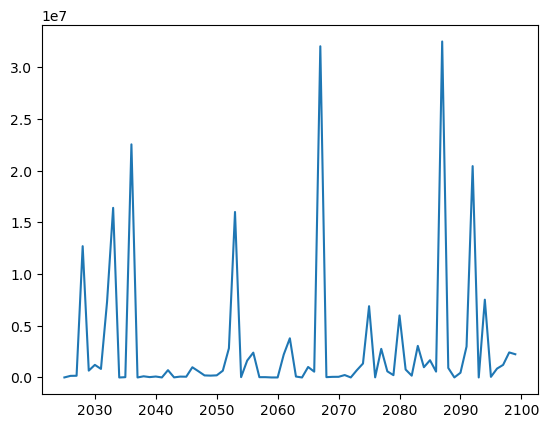

In [39]:
plt.plot(aggregated_world.index, aggregated_world["mean"], label="Moyenne")

## Visualisation - Exemple USA

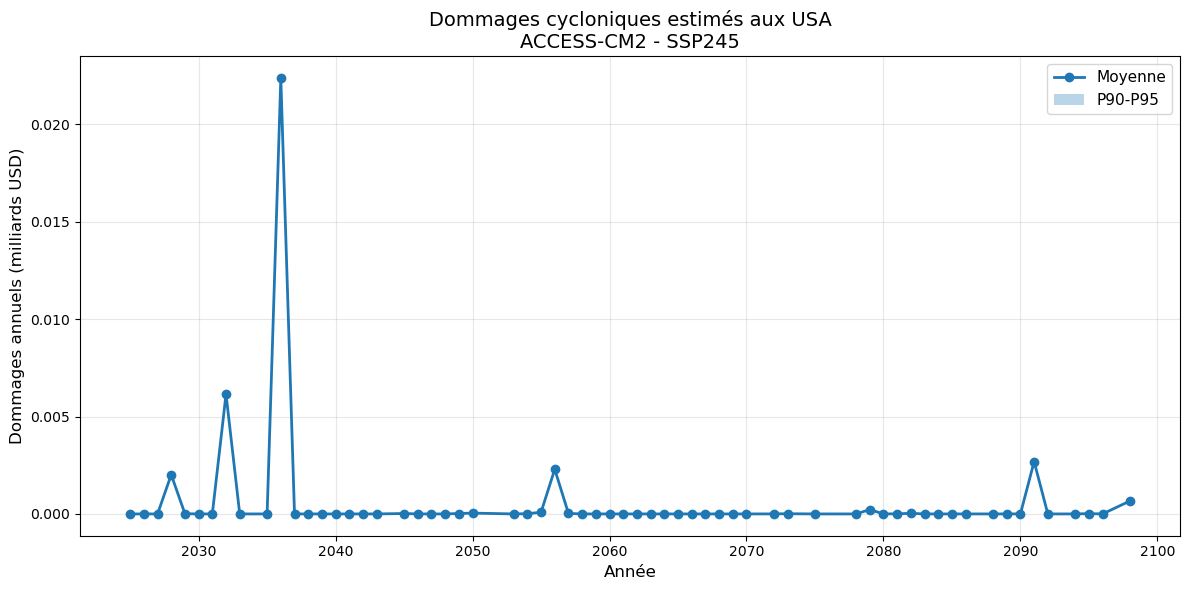


Résumé USA:
  Dommage moyen par année: 0.00 G$
  Dommage max par année: 0.02 G$


In [42]:
# Visualiser les dommages moyens par année pour les USA (si disponible)
usa_stats = statistics[statistics["country_iso2"] == "US"]

if len(usa_stats) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(
        usa_stats["year"],
        usa_stats["mean"] / 1e9,
        label="Moyenne",
        marker="o",
        linewidth=2,
    )
    ax.fill_between(
        usa_stats["year"],
        usa_stats["p90"] / 1e9,
        usa_stats["p95"] / 1e9,
        alpha=0.3,
        label="P90-P95",
    )
    
    ax.set_xlabel("Année", fontsize=12)
    ax.set_ylabel("Dommages annuels (milliards USD)", fontsize=12)
    ax.set_title(
        f"Dommages cycloniques estimés aux USA\n"
        f"{model} - {experiment.upper()}",
        fontsize=14,
    )
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nRésumé USA:")
    print(f"  Dommage moyen par année: {usa_stats['mean'].mean() / 1e9:.2f} G$")
    print(f"  Dommage max par année: {usa_stats['max'].max() / 1e9:.2f} G$")
else:
    print("USA non trouvé dans les résultats")

## Résumé des résultats

In [43]:
print("\n" + "="*60)
print("RÉSUMÉ DU CALCUL DES DOMMAGES")
print("="*60)

print(f"\nModèle: {model}")
print(f"Expérience: {experiment}")
print(f"\nRésultats générés:")
print(f"  • Fichiers par pays: {len(output_files)} pays traités")
print(f"  • Données brutes: {all_damages.shape[0]:,} événements")
print(f"  • Données agrégées: {aggregated.shape[0]:,} lignes")
print(f"  • Période: {statistics['year'].min()}-{statistics['year'].max()}")
print(f"\nFichiers de sortie:")
print(f"  • Dommages détaillés: {output_dir / '*.parquet'}")
print(f"  • Agrégation: {agg_file}")
print(f"  • Statistiques: {stats_file}")
print(f"\nTotal dommages (tous pays, tous seeds):")
print(f"  • Somme: {all_damages['absolute_losses'].sum() / 1e12:.2f} T$")
print(f"  • Moyenne par événement: {all_damages['absolute_losses'].mean() / 1e6:.2f} M$")
print("\n" + "="*60)


RÉSUMÉ DU CALCUL DES DOMMAGES

Modèle: ACCESS-CM2
Expérience: ssp245

Résultats générés:
  • Fichiers par pays: 73 pays traités
  • Données brutes: 17,639 événements
  • Données agrégées: 1,097 lignes
  • Période: 2025-2099

Fichiers de sortie:
  • Dommages détaillés: ../data/output/damages/by_country/ACCESS-CM2/ssp245/*.parquet
  • Agrégation: ../data/output/damages/by_country/ACCESS-CM2/ssp245/damages_aggregated.parquet
  • Statistiques: ../data/output/damages/by_country/ACCESS-CM2/ssp245/damages_statistics.parquet

Total dommages (tous pays, tous seeds):
  • Somme: 0.00 T$
  • Moyenne par événement: 0.03 M$

